In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Load dataset ---
digits = load_digits()
X, y = digits.data, digits.target
# --- Split into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [3]:
save_data = False

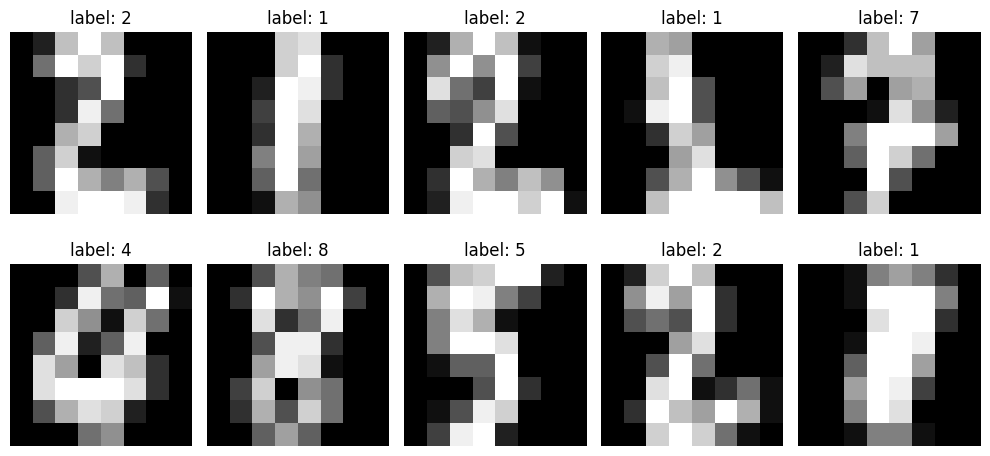

In [4]:
# --- Visualize some predictions ---
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"label: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
if save_data: plt.savefig('Pics/load_digits_samples.pdf', transparent=True)
plt.show()

KNN (k=5): accuracy = 0.9844
Random Forest: accuracy = 0.9600
SVM (RBF kernel): accuracy = 0.9889


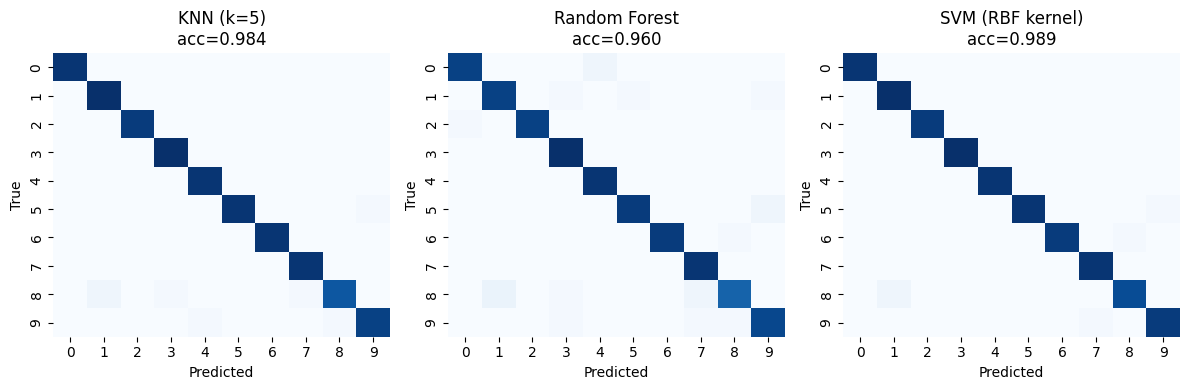

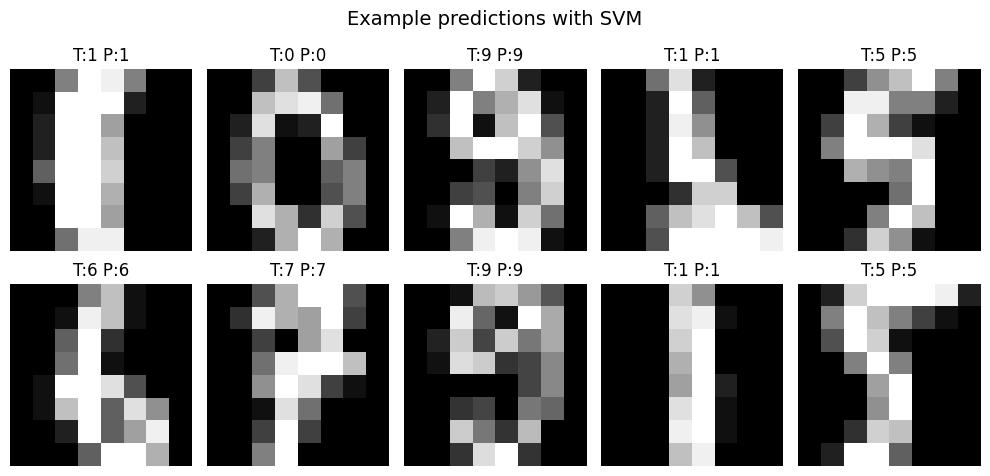

In [5]:
# 🌙 Handwritten digits classification with multiple ML methods
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Define classifiers ---
models = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF kernel)": SVC(kernel="rbf", gamma=0.001, C=10, random_state=42),
}

# --- Train and evaluate ---
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (acc, y_pred)
    print(f"{name}: accuracy = {acc:.4f}")

# --- Plot confusion matrices ---
nmodels = len(models)
fig, axes = plt.subplots(1, nmodels, figsize=(4*nmodels, 4))
for ax, (name, (acc, y_pred)) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\nacc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
if save_data: plt.savefig('Pics/load_digits_confusion_matrices.pdf', transparent=True)
plt.show()

# --- Show a few test examples with predictions ---
chosen_model = models["SVM (RBF kernel)"]
y_pred = results["SVM (RBF kernel)"][1]
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"T:{y_test[i]} P:{y_pred[i]}")
    ax.axis("off")
plt.suptitle("Example predictions with SVM", fontsize=14)
plt.tight_layout()
if save_data: plt.savefig('Pics/load_digits_example_SVM_predictions.pdf', transparent=True)
plt.show()


✨ AdaBoost accuracy: 0.911

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        45
           1       0.88      0.76      0.81        46
           2       0.98      0.91      0.94        44
           3       0.90      0.96      0.93        46
           4       0.95      0.93      0.94        45
           5       0.96      0.93      0.95        46
           6       0.96      0.96      0.96        45
           7       0.93      0.96      0.95        45
           8       0.74      0.91      0.81        43
           9       0.87      0.89      0.88        45

    accuracy                           0.91       450
   macro avg       0.92      0.91      0.91       450
weighted avg       0.92      0.91      0.91       450



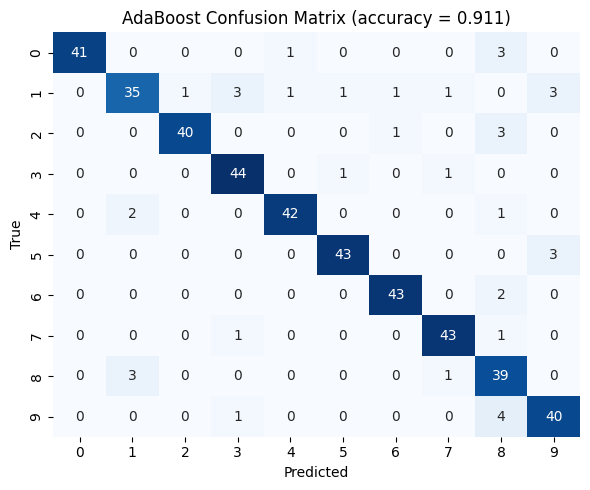

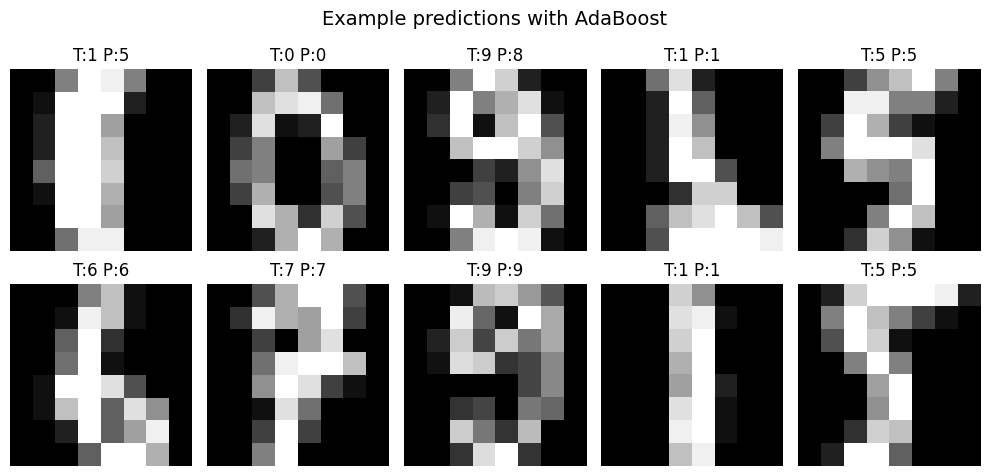

In [6]:
# 🌙 AdaBoost classification on the handwritten digits dataset

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Define the base (weak) learner ---
base_tree = DecisionTreeClassifier(max_depth=2, random_state=42)

# --- Define AdaBoost classifier ---
ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,     # number of boosting rounds
    learning_rate=0.8,    # controls contribution of each tree
    random_state=42
)

# --- Train the model ---
ada.fit(X_train, y_train)

# --- Predict and evaluate ---
y_pred = ada.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"✨ AdaBoost accuracy: {acc:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"AdaBoost Confusion Matrix (accuracy = {acc:.3f})")
plt.tight_layout()
plt.show()

# --- Show some example predictions ---
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"T:{y_test[i]} P:{y_pred[i]}")
    ax.axis("off")
plt.suptitle("Example predictions with AdaBoost", fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
# 🌙 Handwritten digits classification with multiple ML methods
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB

base_tree = DecisionTreeClassifier()
clf_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,          # number of trees
    max_samples=0.8,          # each tree sees 80% of data
    bootstrap=True,           # sampling with replacement
    random_state=42
)
ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,     # number of boosting rounds
    learning_rate=0.8,    # controls contribution of each tree
    random_state=42
)
# --- Define classifiers ---
models = {
    "DecisionTree" : base_tree,
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF kernel)": SVC(kernel="rbf", gamma=0.001, C=10, random_state=42),
    "Bagging" : clf_bagging,
    "AdaBoost" : ada,
    "NaiveBayes" : GaussianNB(),
}

# --- Train and evaluate ---
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (acc, y_pred)
    print(f"{name}: accuracy = {acc:.4f}")

DecisionTree: accuracy = 0.8378
KNN (k=5): accuracy = 0.9844
Random Forest: accuracy = 0.9600
SVM (RBF kernel): accuracy = 0.9889
Bagging: accuracy = 0.9222
AdaBoost: accuracy = 0.8200
NaiveBayes: accuracy = 0.8289


✨ ELM accuracy: 98.7%


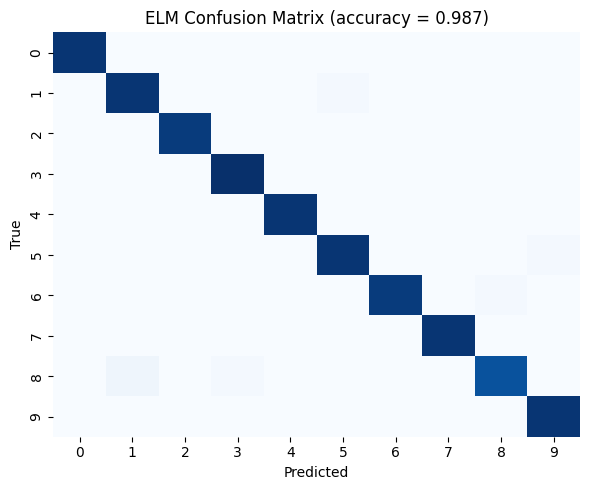

In [8]:
# 🌙 Extreme Learning Machine (ELM) on handwritten digits
from ELM import ELM
from sklearn.preprocessing import OneHotEncoder

# --- Load data ---
digits = load_digits()
X, y = digits.data, digits.target

# --- One-hot encode labels ---
enc = OneHotEncoder(sparse_output=False)
Y = enc.fit_transform(y.reshape(-1, 1))

# --- Train-test split ---
X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.25, random_state=42, stratify=y
)

np.random.seed(125)
elm = ELM(n_hidden=30000)
elm.fit(X_train,Y_train)
Y_pred= elm.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)
# --- Evaluation ---
acc = accuracy_score(y_test, y_pred)
print(f"✨ ELM accuracy: {100*acc:.1f}%")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=False, cmap="Blues", cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"ELM Confusion Matrix (accuracy = {acc:.3f})")
plt.tight_layout()
plt.show()

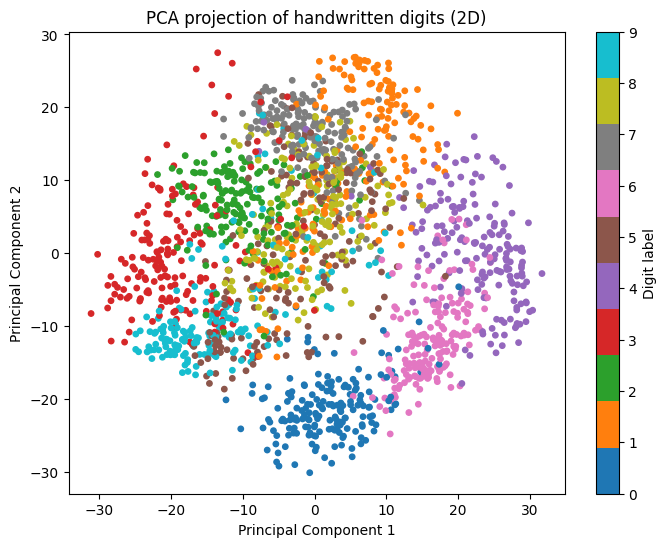

Explained variance by first 2 PCs: 0.28509364823699285


In [9]:
# 🌙 PCA method characterization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# --- 3. Plot the projection ---
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', s=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of handwritten digits (2D)")
plt.colorbar(scatter, label="Digit label")
if save_data: plt.savefig('Pics/PCA_2D_projection.pdf', transparent=True)
plt.show()

# --- 4. Print explained variance ratio ---
print("Explained variance by first 2 PCs:", pca.explained_variance_ratio_.sum())

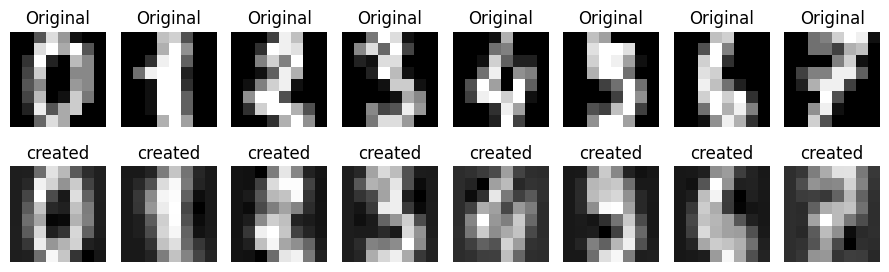

In [10]:
from PCA_law import PCA_law, PCA_classifier

n_components=13
pp = PCA_law(n_components= n_components)
pp.fit(X)
ycomp = pp.compress(X)
Xrec = pp.reconstruct(ycomp)

# Compare original and reconstructed digits
fig, axes = plt.subplots(2, 8, figsize=(9, 3))
for i in range(8):
    axes[0, i].imshow(X[i].reshape(8,8), cmap='gray')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(Xrec[i].reshape(8,8), cmap='gray')
    axes[1, i].set_title("created")
    for ax in axes[:, i]: ax.axis('off')
plt.tight_layout()
if save_data: plt.savefig('Pics/PCA_13D_reconstruction.pdf', transparent=True)
plt.show()

✨ PCA_law accuracy: 98.4%


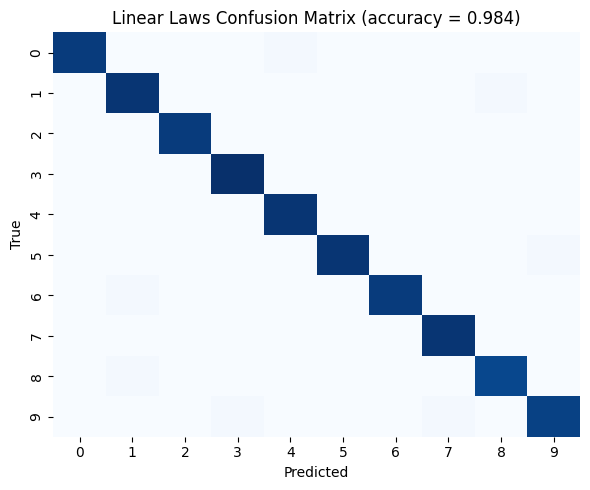

In [11]:
pcl = PCA_classifier(n_components= 15)
pcl.fit(X_train,y_train)
y_pred = pcl.predict(X_test)
# --- Evaluation ---
acc = accuracy_score(y_test, y_pred)
print(f"✨ PCA_law accuracy: {100*acc:.1f}%")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=False, cmap="Blues", cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Linear Laws Confusion Matrix (accuracy = {acc:.3f})")
plt.tight_layout()
plt.show()

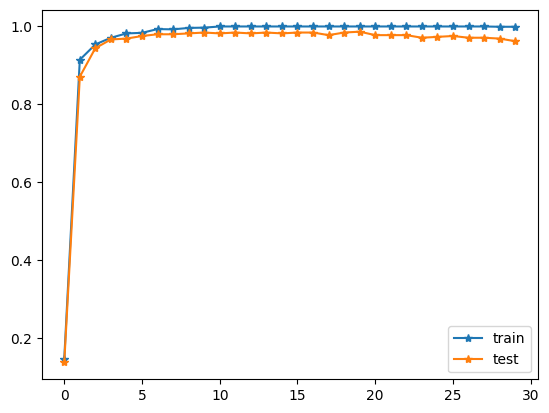

In [12]:
acc_list=[]
n_comp_list = range(30)
for n_comp in n_comp_list:
    pcl = PCA_classifier(n_components= n_comp)
    pcl.fit(X_train,y_train)
    acc_list.append([accuracy_score(y_train, pcl.predict(X_train)), accuracy_score(y_test, pcl.predict(X_test))])
acc_list = np.array(acc_list).T
plt.plot(n_comp_list, acc_list[0], "*-", label='train')
plt.plot(n_comp_list, acc_list[1], "*-", label='test')
plt.legend()

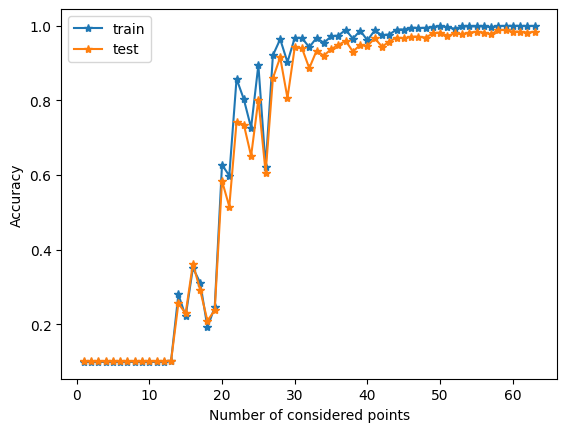

In [13]:
yrange = sorted(set(y))
Xmax = X.max()
Xmin = X.min()
n_components = 12

np.random.seed(128)
result = []
for Ninputs in range(1,64):
    sensor = np.array(sorted(np.random.choice(64, Ninputs, replace=False)))
    pcl = PCA_classifier(n_components= n_components)
    pcl.fit(X_train[:,sensor],y_train)
    y_pred = pcl.predict(X_train[:,sensor])
    acc = accuracy_score(y_train, y_pred)

    y_pred = pcl.predict(X_test[:,sensor])
    acc_1 = accuracy_score(y_test, y_pred)
    result.append([Ninputs, acc, acc_1])
result = np.array(result)
plt.plot(result[:,0], result[:,1], "*-", label='train')
plt.plot(result[:,0], result[:,2], "*-", label='test')
plt.xlabel("Number of considered points")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [14]:
import importlib
import PCA_law

importlib.reload(PCA_law)

from PCA_law import PCA_law, PCA_classifier


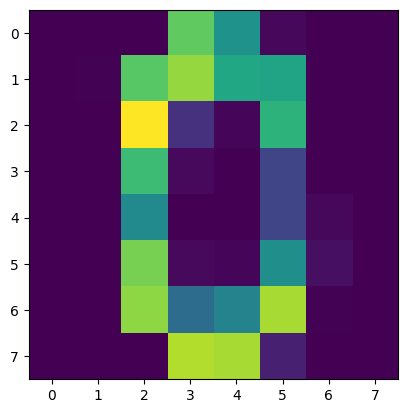

In [23]:
X0 = X[y==0]
plt.imshow(np.sum(X0>12, axis=0).reshape(8,8))

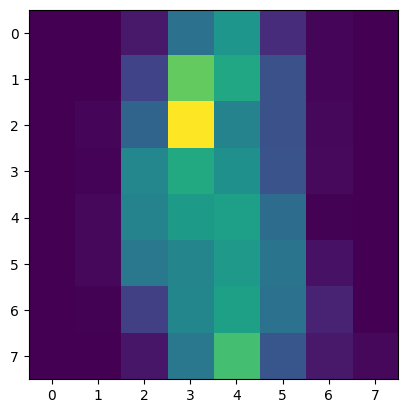

In [39]:
plt.imshow(np.sum(X[X[:,19]>12]>12, axis=0).reshape(8,8))